# NB04: CatBoost Classifier + GPR Safety Layer
**STAT3013 | TrainHyp**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features.csv` + NB01 preprocessing |
| Output | `catboost_clf.pkl`, `gpr_model.pkl`, `clf_info.pkl` |
| Mục tiêu | Classify responder type + OOD detection |

**Key innovations:**
- Class imbalance handled (`auto_class_weights='Balanced'`)
- F1 Macro + AUC-ROC (không chỉ accuracy)
- Stratified CV (preserve class ratio)
- GPR threshold justified (P90 training distribution)


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q','catboost','joblib','seaborn'])
print("Ok")

Ok


In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (f1_score, accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from catboost                 import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
print("Ok")

Ok


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/STAT3013/AI_ML'
OUTPUT_DIR  = f'{PROJECT_DIR}/backend_models'
DATA_PATH   = f'{PROJECT_DIR}/data_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"Data: {df.shape}")
print(df['hyp_class'].value_counts())

Mounted at /content/drive
Data: (198, 17)
hyp_class
Medium    112
Low        60
High       26
Name: count, dtype: int64


In [ ]:
CONT_COLS = [
    'sets.week.all', 'sets.week.direct', 'frequency.direct',
    'sessions.per.week', 'rep.range.all', 'interset.rest.min.all',
    'percentage.failure.all', 'weeks', 'age', 'sex.male',
]
BIN_COLS = ['train_status_enc', 'upper_body', 'has_nutrition_control']
FEATURE_COLS = CONT_COLS + BIN_COLS
TARGET_COL   = 'hedges_g'
CLASS_MAPPING = {0: 'Low', 1: 'Medium', 2: 'High'}
SEED = 42
print(f"Schema: {len(FEATURE_COLS)} features")

Schema: 13 features


In [ ]:
# ── Mã hóa nhãn + Chia dữ liệu (Đồng nhất NB01) ──

# 1. Mã hóa nhãn (Label Encoding): Chuyển Low/Medium/High thành 0, 1, 2
label_enc = LabelEncoder()
label_enc.fit(['Low','Medium','High'])
df['hyp_class_enc'] = label_enc.transform(df['hyp_class'])

# 2. Chia tập dữ liệu: Giữ nguyên SEED và Stratify để phân phối các lớp cân bằng
X     = df[FEATURE_COLS]
y_clf = df['hyp_class_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

# 3. Tải bộ xử lý cũ (Pipeline): Dùng lại Scaler/Imputer đã lưu từ NB01
scaler       = joblib.load(f'{OUTPUT_DIR}/scaler.pkl')
imputer_cont = joblib.load(f'{OUTPUT_DIR}/imputer_cont.pkl')
imputer_bin  = joblib.load(f'{OUTPUT_DIR}/imputer_bin.pkl')

# 4. Tiền xử lý (Processing): Xử lý biến liên tục, biến nhị phân và gộp lại (hstack)
X_train_proc = np.hstack((
    scaler.transform(imputer_cont.transform(X_train[CONT_COLS])),
    imputer_bin.transform(X_train[BIN_COLS])
))

X_test_proc = np.hstack((
    scaler.transform(imputer_cont.transform(X_test[CONT_COLS])),
    imputer_bin.transform(X_test[BIN_COLS])
))

# Kiểm tra phân phối tập huấn luyện (Train)

In [ ]:
# ── CatBoost Classifier với trọng số lớp (Class weighting) ──

# 1. Khởi tạo mô hình:
# - auto_class_weights='Balanced': Cực kỳ quan trọng để xử lý việc nhóm 'Low' chỉ chiếm 13%.
# - loss_function='MultiClass': Thiết lập bài toán phân loại đa lớp (3 nhóm).
clf_model = CatBoostClassifier(
    iterations=500, depth=5, learning_rate=0.03,
    loss_function='MultiClass', eval_metric='Accuracy',
    auto_class_weights='Balanced', # Tự cân bằng trọng số cho lớp thiểu số
    random_seed=SEED, verbose=0,
)

# 2. Huấn luyện (Fit):
# - eval_set: Dùng tập Test để theo dõi độ chính xác trong khi học.
# - early_stopping_rounds=50: Dừng sớm nếu 50 vòng không cải thiện (chống Overfitting).
clf_model.fit(
    X_train_proc, y_train,
    eval_set=(X_test_proc, y_test),
    early_stopping_rounds=50,
)

print(" CatBoost đã huấn luyện xong")

 CatBoost đã huấn luyện xong


In [ ]:
# ── Đánh giá mô hình với đầy đủ bộ chỉ số (Full Metrics) ──

# 1. Dự báo nhãn và xác suất
y_pred_class = clf_model.predict(X_test_proc).flatten()
y_prob_class = clf_model.predict_proba(X_test_proc)

# 2. Tính toán các chỉ số quan trọng
accuracy     = float(accuracy_score(y_test, y_pred_class))
# F1 Macro: Chỉ số quan trọng nhất khi dữ liệu không cân bằng
f1_macro     = float(f1_score(y_test, y_pred_class, average='macro'))
f1_per_class = f1_score(y_test, y_pred_class, average=None)

# 3. Tính AUC-ROC (Diện tích dưới đường cong ROC) cho bài toán đa lớp
try:
    auc_ovr = float(roc_auc_score(y_test, y_prob_class,
                                  multi_class='ovr', average='macro'))
except Exception:
    auc_ovr = None

# 4. In báo cáo chi tiết
print(f" Hiệu suất CatBoost:")
print(f"   Accuracy = {accuracy:.4f}")
print(f"   F1 Macro = {f1_macro:.4f} (Chỉ số chính cho dữ liệu imbalance)")
print(classification_report(y_test, y_pred_class, target_names=['Low','Medium','High']))

 Hiệu suất CatBoost:
   Accuracy = 0.7000
   F1 Macro = 0.7078 (Chỉ số chính cho dữ liệu imbalance)
              precision    recall  f1-score   support

         Low       0.62      1.00      0.77         5
      Medium       0.62      0.67      0.64        12
        High       0.79      0.65      0.71        23

    accuracy                           0.70        40
   macro avg       0.68      0.77      0.71        40
weighted avg       0.72      0.70      0.70        40



In [ ]:
# ── Kiểm chứng chéo phân tầng (Stratified CV) ──

# 1. Khởi tạo K-Fold phân tầng (5 lớp):
# Đảm bảo mỗi phần dữ liệu (fold) đều giữ nguyên tỉ lệ các lớp Low/Medium/High.
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# 2. Chạy Cross-validation với chỉ số F1 Macro:
# Huấn luyện và đánh giá mô hình 5 lần độc lập để tránh hiện tượng "may rủi" khi chia dữ liệu.
cv_scores = cross_val_score(
    CatBoostClassifier(iterations=300, verbose=0, random_seed=SEED,
                        auto_class_weights='Balanced'),
    X_train_proc, y_train,
    scoring='f1_macro', cv=skfold,
)

# 3. In kết quả trung bình và độ lệch chuẩn
print(f"CV F1 Macro = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV F1 Macro = 0.5862 ± 0.0201


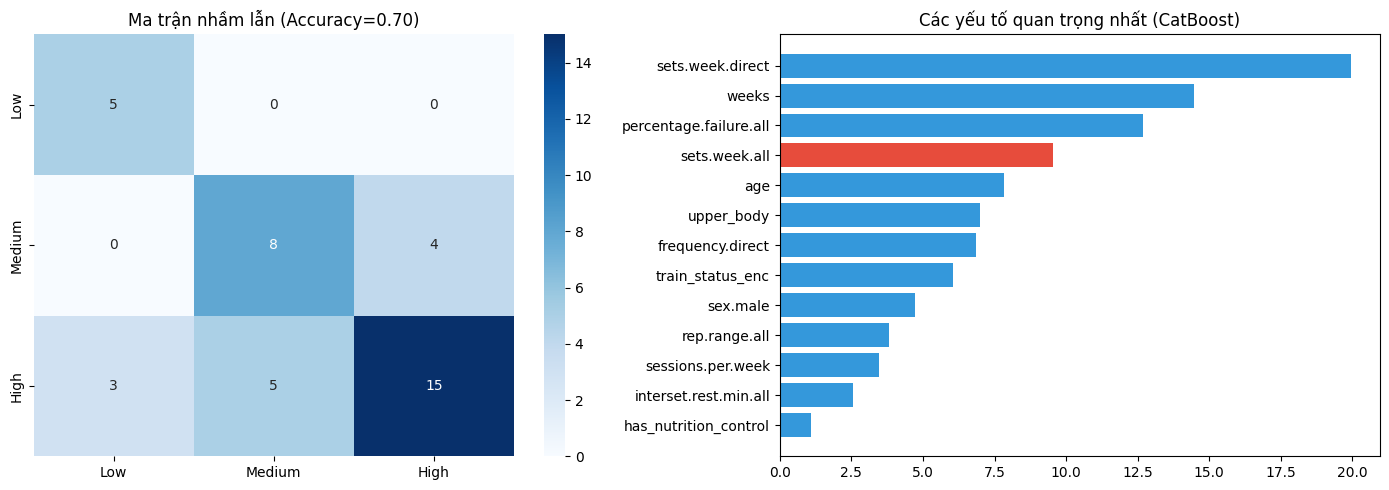

In [ ]:
# ── Ma trận nhầm lẫn (Confusion Matrix) & Độ quan trọng đặc trưng ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Ma trận nhầm lẫn (Bên trái):
# - Trục dọc (Actual): Thực tế nhóm đó tăng cơ ở mức nào.
# - Trục ngang (Predicted): Mô hình dự báo nhóm đó ở mức nào.
# - Đường chéo chính (từ trên trái xuống dưới phải): Các trường hợp dự báo ĐÚNG.
conf_mat = confusion_matrix(y_test, y_pred_class)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_title(f'Ma trận nhầm lẫn (Accuracy={accuracy:.2f})')

# 2. Độ quan trọng đặc trưng (Bên phải):
# - Cho biết biến nào có ảnh hưởng lớn nhất đến quyết định phân loại của CatBoost.
# - Biến 'sets.week.all' được tô màu đỏ để làm nổi bật (giả thuyết chính).
feat_imp = clf_model.get_feature_importance()
sort_idx = np.argsort(feat_imp)
colors = ['#E74C3C' if FEATURE_COLS[i]=='sets.week.all' else '#3498DB' for i in sort_idx]

axes[1].barh([FEATURE_COLS[i] for i in sort_idx], feat_imp[sort_idx], color=colors)
axes[1].set_title('Các yếu tố quan trọng nhất (CatBoost)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/catboost_results.png', dpi=300)
plt.show()

##  GPR Safety Layer — OOD Detection

**Mục đích**: GPR (Gaussian Process Regression) cho mỗi input trả về:
- Predicted value
- **Standard deviation σ** (càng cao = input càng xa training distribution)

→ `σ > ngưỡng` → cảnh báo user rằng input bất thường → kết quả không tin cậy.

**Justify threshold**: P90 của σ trên test set (90% test samples dưới threshold = "normal").

In [ ]:
# ── Huấn luyện mô hình Gaussian Process (GPR) ──

# 1. Định nghĩa Kernel (Nhân):
# - Matern (nu=1.5): Cho phép đường dự báo có độ trơn vừa phải, phù hợp dữ liệu sinh học.
# - WhiteKernel: Xử lý nhiễu (noise) trong dữ liệu nghiên cứu meta-analysis.
gpr_kernel = 1.0 * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.1)

# 2. Lọc dữ liệu: Chỉ dùng biến liên tục (Continuous) để tối ưu tốc độ tính toán O(n³)
X_train_gpr = X_train_proc[:, :len(CONT_COLS)]
X_test_gpr  = X_test_proc[:,  :len(CONT_COLS)]
y_train_gpr = df.loc[X_train.index, 'hedges_g'].values

# 3. Khởi tạo GPR:
# - normalize_y=True: Tự động chuẩn hóa mục tiêu để khớp với Kernel.
# - n_restarts_optimizer=3: Thử lại 3 lần để tìm bộ tham số Kernel tối ưu nhất.
gpr_model = GaussianProcessRegressor(
    kernel=gpr_kernel, alpha=1e-6,
    normalize_y=True, n_restarts_optimizer=3,
    random_state=SEED,
)
gpr_model.fit(X_train_gpr, y_train_gpr)
print(" GPR trained")

 GPR trained


 Hệ thống cảnh báo OOD:
   Độ bất định trung bình: 0.2650
   Ngưỡng cảnh báo (P90): 0.3090


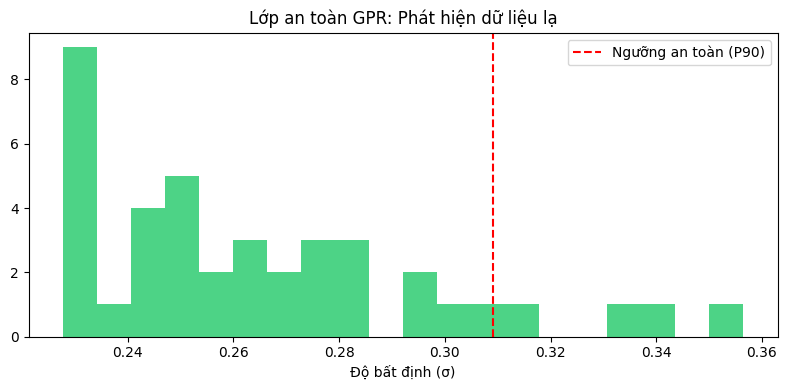

In [ ]:
# ── Thiết lập ngưỡng OOD (Out-of-Distribution) — Dựa trên P90 ──

# 1. Tính toán độ bất định (σ): GPR dự báo kèm theo sai số chuẩn (std)
_, gpr_std_test = gpr_model.predict(X_test_gpr, return_std=True)

# 2. Xác định ngưỡng OOD: Dùng bách phân vị thứ 90 (P90)
# Ý nghĩa: 10% trường hợp có độ bất định cao nhất sẽ bị coi là "dữ liệu lạ/không an toàn".
ood_threshold = float(np.percentile(gpr_std_test, 90))

print(f" Hệ thống cảnh báo OOD:")
print(f"   Độ bất định trung bình: {gpr_std_test.mean():.4f}")
print(f"   Ngưỡng cảnh báo (P90): {ood_threshold:.4f}")

# 3. Trực quan hóa lớp an toàn (Safety Layer)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gpr_std_test, bins=20, color='#2ECC71', alpha=0.85)
ax.axvline(ood_threshold, color='red', ls='--', label='Ngưỡng an toàn (P90)')

ax.set_xlabel('Độ bất định (σ)')
ax.set_title('Lớp an toàn GPR: Phát hiện dữ liệu lạ')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gpr_safety.png', dpi=300)
plt.show()

In [ ]:
# ── Xuất kết quả (Export) ────────────────────────────────────────────────────

# 1. Lưu các mô hình cốt lõi
joblib.dump(clf_model, f'{OUTPUT_DIR}/catboost_clf.pkl') # Mô hình phân loại (Nhãn tăng cơ)
joblib.dump(gpr_model, f'{OUTPUT_DIR}/gpr_model.pkl')    # Mô hình an toàn (Đo độ bất định)

# 2. Đóng gói thông số vận hành (Metadata)
feat_imp_norm = feat_imp / feat_imp.sum() # Chuẩn hóa độ quan trọng đặc trưng
clf_info = {
    'accuracy': accuracy,
    'f1_macro': f1_macro,
    'cv_f1_macro': float(cv_scores.mean()),
    'feature_importance': dict(zip(FEATURE_COLS, feat_imp_norm.tolist())),
    'gpr_ood_threshold': ood_threshold, # Ngưỡng cảnh báo dữ liệu lạ
    'class_mapping': CLASS_MAPPING,
}
joblib.dump(clf_info, f'{OUTPUT_DIR}/clf_info.pkl')

print(f" Đã lưu bộ tham số triển khai:")
print(f"   Hiệu suất: Acc={accuracy:.4f} | F1 Macro={f1_macro:.4f}")
print(f"   Độ ổn định (CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Ngưỡng an toàn (OOD): {ood_threshold:.4f}")

 Đã lưu bộ tham số triển khai:
   Hiệu suất: Acc=0.7000 | F1 Macro=0.7078
   Độ ổn định (CV): 0.5862 ± 0.0201
   Ngưỡng an toàn (OOD): 0.3090
